In [118]:
# 載入相關函式庫
import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
import pandas as pd
import matplotlib.pyplot as plt

In [119]:
# 1️. 載入數據集
iris = load_iris()
X = iris.data  # (150, 4)
y = iris.target.reshape(-1, 1)  # (150, 1)
# One-hot encoding labels
encoder = OneHotEncoder(sparse_output=False)
Y = encoder.fit_transform(y)  # (150, 3)
# 一覽資料內容
print(iris.target_names)    # target 分別 0:setosa 1:versicolor 2:virginica
pd.set_option('display.width', 500)
pd.option_context('display.max_rows',10)
df_with_columns = pd.DataFrame(np.hstack((X,y)), columns=iris.feature_names+['target'])
print(df_with_columns)


['setosa' 'versicolor' 'virginica']
     sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  target
0                  5.1               3.5                1.4               0.2     0.0
1                  4.9               3.0                1.4               0.2     0.0
2                  4.7               3.2                1.3               0.2     0.0
3                  4.6               3.1                1.5               0.2     0.0
4                  5.0               3.6                1.4               0.2     0.0
..                 ...               ...                ...               ...     ...
145                6.7               3.0                5.2               2.3     2.0
146                6.3               2.5                5.0               1.9     2.0
147                6.5               3.0                5.2               2.0     2.0
148                6.2               3.4                5.4               2.3     2.0
149               

In [ ]:
# 2. 預處理數據
#標準化特徵
X = (X - np.mean(X, axis=0)) / np.std(X, axis=0)    # z-score 標準化度量

# 分割訓練與測試集
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [121]:
# 3. 設計神經網絡結構（輸入層、隱藏層、輸出層）
input_size = X_train.shape[1]   # 輸入層每ㄧ訓練樣本的特徵數
hidden_size = 10    # 隱藏層 10個神經元
output_size = 3     # 輸出層3個類別

In [122]:
# 4.初始化權重和偏置
np.random.seed(42)
W1 = np.random.randn(input_size, hidden_size) * 0.01
b1 = np.zeros((1, hidden_size))
W2 = np.random.randn(hidden_size, output_size) * 0.01
b2 = np.zeros((1, output_size))

In [ ]:
def sigmoid(Z):
    return 1 / (1 + np.exp(-Z))
def sigmoid_derivative(A):
    return A * (1 - A)
def softmax(Z):    
    # expZ = np.exp(Z - np.max(Z, axis=1, keepdims=True)) # axis=1 依每列(row)最大值
    expZ = np.exp(Z)
    return expZ / expZ.sum(axis=1, keepdims=True)       # axis=1 依每列(row)加總

# 5.前向傳播
def forward(X):
    A0=X.copy()     # X與A0一對一複製
    # 隱藏層前向傳播
    Z1 = A0.dot(W1) + b1    
    A1 = sigmoid(Z1)   
    # 輸出層前向傳播
    Z2 = A1.dot(W2) + b2    
    A2 = softmax(Z2)
    cache = (X, Z1, A1, Z2, A2)
    return A2, cache

# 6.Cross-entropy loss
def compute_loss(Y_pred, Y_true):
    m = Y_true.shape[0]     # 樣本筆數
    loss = -np.sum(Y_true * np.log(Y_pred + 1e-8)) / m      # 平均損失(交叉熵)
    return loss
# 7.反向傳播
def backward(cache, Y_true):
    X, Z1, A1, Z2, A2 = cache
    m = X.shape[0]      # 訓練樣本數

    # 輸出層梯度
    dZ2 = A2 - Y_true 

    # 隱藏層到輸出層的梯度  
    dW2 = A1.T.dot(dZ2) / m
    db2 = np.sum(dZ2, axis=0, keepdims=True) / m

    dA1 = dZ2.dot(W2.T)
    dZ1 = dA1 * sigmoid_derivative(A1)   #  改為 Sigmoid 導數
    # 輸入層到隱藏層的梯度
    dW1 = X.T.dot(dZ1) / m
    db1 = np.sum(dZ1, axis=0, keepdims=True) / m

    return dW1, db1, dW2, db2
# 8. 更新參數(權重)
def update_params(W1, b1, W2, b2, grads, lr=0.1):
    dW1, db1, dW2, db2 = grads
    W1 -= lr * dW1
    b1 -= lr * db1
    W2 -= lr * dW2
    b2 -= lr * db2
    return W1, b1, W2, b2

# 9. 訓練循環
epochs = 1000
learning_rate = 0.1
losses = []
for i in range(epochs):
    Y_pred, cache = forward(X_train)
    loss = compute_loss(Y_pred, Y_train)
    grads = backward(cache, Y_train)
    W1, b1, W2, b2 = update_params(W1, b1, W2, b2, grads, lr=learning_rate)
    losses.append(loss)
    if i % 100 == 0:
        print(f"Epoch {i}: Loss = {loss:.4f}")

Epoch 0: Loss = 1.0985
Epoch 100: Loss = 1.0901
Epoch 200: Loss = 0.7957


Epoch 300: Loss = 0.4947
Epoch 400: Loss = 0.3945
Epoch 500: Loss = 0.3330
Epoch 600: Loss = 0.2872
Epoch 700: Loss = 0.2505
Epoch 800: Loss = 0.2200
Epoch 900: Loss = 0.1947


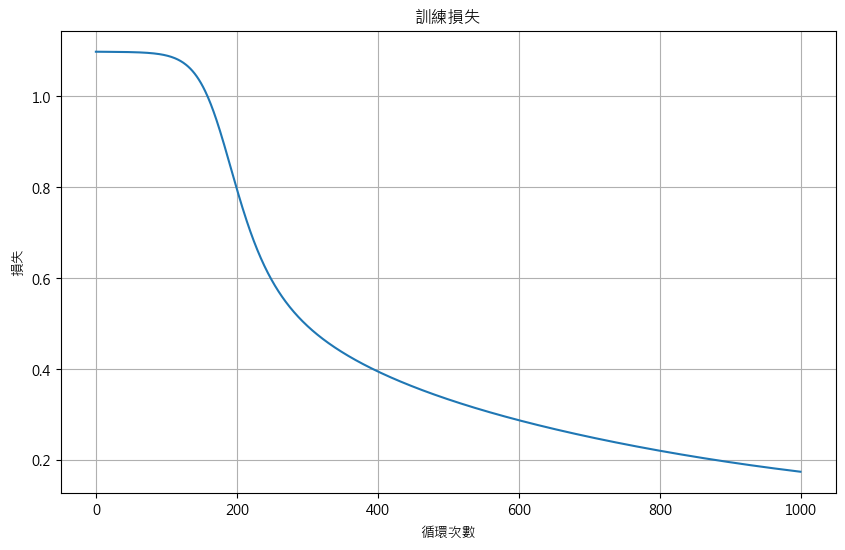

In [124]:
# 繪製損失曲線

#  設定字體
plt.rcParams['font.sans-serif'] = ['Microsoft JhengHei']  # 用於正常顯示中文標籤
plt.rcParams['axes.unicode_minus'] = False  # 用於正常顯示負號(若有負數資料)
plt.figure(figsize=(10, 6))
plt.plot(losses)
plt.title('訓練損失')
plt.xlabel('循環次數')
plt.ylabel('損失')
plt.grid(True)
# plt.show()
plt.savefig('converge.svg')

In [17]:

#10.評估模型(準確率)
def predict(X): # 預測
    y_hat = forward(X)
    return np.argmax(np.array(y_hat[0]))
Y_pred_test, _ = forward(X_test)
pred_labels = np.argmax(Y_pred_test, axis=1)
true_labels = np.argmax(Y_test, axis=1)
accuracy = np.mean(pred_labels == true_labels)
print(f"\n預測準確率: {accuracy*100:.2f}%")
#顯示一些預測示例
print("\n預測示例:")
sample_indices = np.random.choice(len(X_test), 5, replace=False)
for idx in sample_indices:
    predicted = predict(X_test[idx])
    actual = np.argmax(Y_test[idx])
    print(f"實際: {actual}, 預測: {predicted}, {'正確' if actual == predicted else '錯誤'}")


預測準確率: 100.00%

預測示例:
實際: 2, 預測: 2, 正確
實際: 0, 預測: 0, 正確
實際: 2, 預測: 2, 正確
實際: 0, 預測: 0, 正確
實際: 0, 預測: 0, 正確
